# Procesamiento de Imágenes
## Sesión práctica 5
Profesor: Cristóbal Loyola<br>
Ayudante: Clemente Aguilar<br>
<br>Universidad de Santiago de Chile, 2025

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, color
from skimage.exposure import rescale_intensity
from skimage.util import img_as_ubyte
from skimage.color import rgb2gray
from skimage import exposure
from skimage.io import imread
from skimage.filters import threshold_otsu
import cv2
import os

In [44]:
def show_images(original, transformed=None, title=None):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title('Original')
    plt.imshow(original, cmap='gray')
    plt.axis('off')

    if transformed is not None and title is not None:
        plt.subplot(1, 2, 2)
        plt.title(title)
        plt.imshow(transformed, cmap='gray')
        plt.axis('off')
        plt.show()

def get_coords_grid(height, width):
    x, y = np.meshgrid(np.arange(width), np.arange(height))
    ones = np.ones_like(x)
    coords = np.stack([x, y, ones], axis=0)
    # coordenadas homogéneas (como aparecen en la diapositiva 11)
    return coords.reshape(3, -1)  # shape: (3, H*W) -> fila1: x, fila2: y, fila3: 1

In [45]:
# Ejemplo de tratamiento de imagen con más de 3 canales.
img = data.lily()
print(img.shape)
rgb_img = img[:, :, :3]
print(f"Valor mínimo: {np.min(rgb_img)}")
print(f"Valor máximo: {np.max(rgb_img)}")

rgb_scaled = (rgb_img / np.max(rgb_img)) * 255
rgb_uint8 = rgb_scaled.astype(np.uint8)

#show_image(rgb_uint8)

(922, 922, 4)
Valor mínimo: 0
Valor máximo: 4095


## Cargar la imagen de esta sesión
Para esta sesión se utilizará la imagen `rocket` desde Scikit-Image.<br>
Si lo deseas, se disponen bloques para que puedas cargar tu propia imagen independientemente del entorno de trabajo que utilices.

(427, 640, 3)


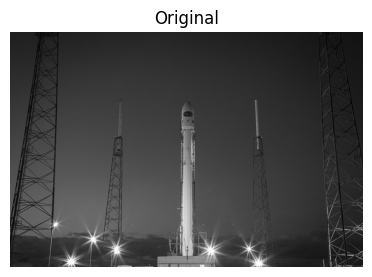

In [46]:
# Imagen a utilizar en la sesión. Siéntanse en total libertad de cargar sus
# propias imágenes para esta experiencia utilizando imágenes públicas o
img = data.rocket()
print(img.shape)

# 1. Si estás trabajando en Google Colab y tienes tu imagen en Drive
"""
from google.colab import drive
drive.mount('/content/drive')

path = "ruta/a/tu/imagen.jpg"
img = imread(path)

# Asegurarse de estar trabajando sobre una imagen con 3 canales RGB usando
# img.shape y su tratamiento posterior necesario
"""

# 2. Si estás trabajando en un entorno local (no Google Colab o Jupyter Notebook)
"""
# Cargar imagen desde una ruta local
path = "ruta/a/tu/imagen.jpg"
img = imread(path)

# Asegurarse de estar trabajando sobre una imagen con 3 canales RGB usando
# img.shape y su tratamiento posterior necesario
"""

# 3. Si deseas trabajar sobre una imagen encontrada en la web
"""
url = "https://www.url/de/tu/imagen.jpg"
img = imread(url)

# Asegurarse de estar trabajando sobre una imagen con 3 canales RGB usando
# img.shape y su tratamiento posterior necesario
"""

gray_img = rgb2gray(img)
show_images(gray_img)

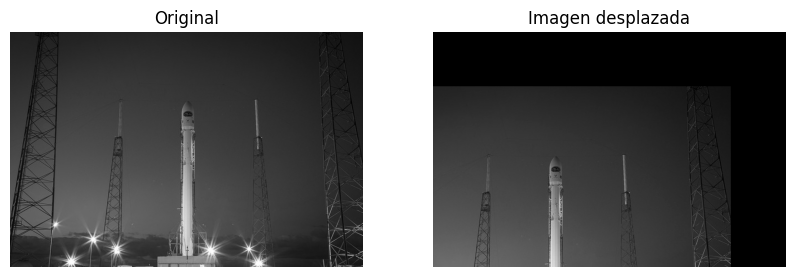

In [49]:
def translate_image(image, dx, dy):
    rows, cols = image.shape
    T = np.array([[1, 0, -dx],
                  [0, 1, -dy],
                  [0, 0, 1]])

    coords = get_coords_grid(rows, cols)
    inv_coords = T @ coords
    x_src = np.round(inv_coords[0, :]).astype(int)
    y_src = np.round(inv_coords[1, :]).astype(int)

    out = np.zeros_like(image)
    valid = (0 <= x_src) & (x_src < cols) & (0 <= y_src) & (y_src < rows)
    out[coords[1, valid], coords[0, valid]] = image[y_src[valid], x_src[valid]]

    return out

translated_img = translate_image(gray_img, -100, 100)
show_images(gray_img, translated_img, "Imagen desplazada")

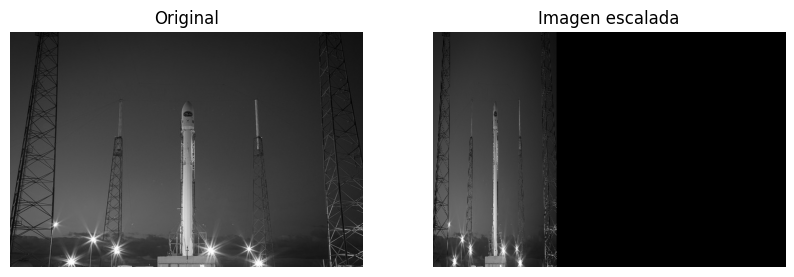

In [53]:
def scale_image(image, sx, sy):
    rows, cols = image.shape
    S = np.array([[1 / sx, 0, 0],
                  [0, 1 / sy, 0],
                  [0, 0, 1]])

    coords = get_coords_grid(rows, cols)
    inv_coords = S @ coords
    x_src = np.round(inv_coords[0, :]).astype(int)
    y_src = np.round(inv_coords[1, :]).astype(int)

    out = np.zeros_like(image)
    valid = (0 <= x_src) & (x_src < cols) & (0 <= y_src) & (y_src < rows)
    out[coords[1, valid], coords[0, valid]] = image[y_src[valid], x_src[valid]]

    return out

scaled_img = scale_image(gray_img, 0.35, 1)
show_images(gray_img, scaled_img, "Imagen escalada")

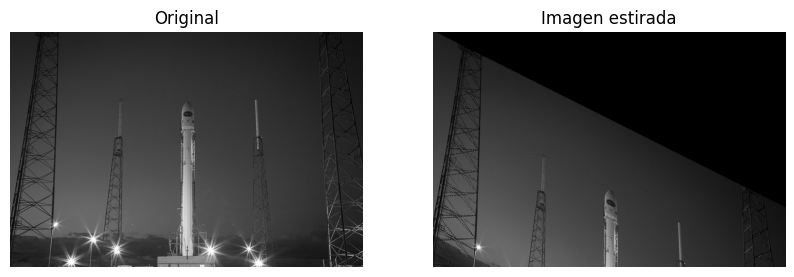

In [58]:
def shear_image(image, bx=0, by=0):
    rows, cols = image.shape
    H = np.array([[1, -bx, 0],
                  [-by, 1, 0],
                  [0, 0, 1]])

    coords = get_coords_grid(rows, cols)
    inv_coords = H @ coords
    x_src = np.round(inv_coords[0, :]).astype(int)
    y_src = np.round(inv_coords[1, :]).astype(int)

    out = np.zeros_like(image)
    valid = (0 <= x_src) & (x_src < cols) & (0 <= y_src) & (y_src < rows)
    out[coords[1, valid], coords[0, valid]] = image[y_src[valid], x_src[valid]]

    return out

sheared_img = shear_image(gray_img, 0, 0.5)
show_images(gray_img, sheared_img, "Imagen estirada")

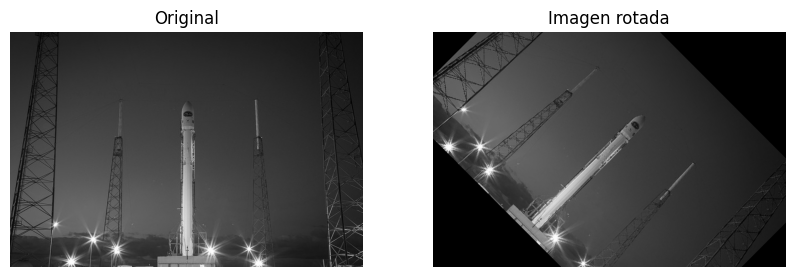

In [56]:
def rotate_image(image, angle_deg):
    angle_rad = np.deg2rad(angle_deg)
    rows, cols = image.shape
    cx, cy = cols / 2, rows / 2

    R = np.array([
        [np.cos(angle_rad), -np.sin(angle_rad), 0],
        [np.sin(angle_rad),  np.cos(angle_rad), 0],
        [0, 0, 1]
    ])

    T = np.array([
        [1, 0, -cx],
        [0, 1, -cy],
        [0, 0, 1]
    ])
    T_inv = np.array([
        [1, 0, cx],
        [0, 1, cy],
        [0, 0, 1]
    ])

    transform = T_inv @ R @ T
    coords = get_coords_grid(rows, cols)
    inv_coords = np.linalg.inv(transform) @ coords

    x_src = np.round(inv_coords[0, :]).astype(int)
    y_src = np.round(inv_coords[1, :]).astype(int)

    out = np.zeros_like(image)
    valid = (0 <= x_src) & (x_src < cols) & (0 <= y_src) & (y_src < rows)
    out[coords[1, valid], coords[0, valid]] = image[y_src[valid], x_src[valid]]

    return out

rotated_img = rotate_image(gray_img, 45)
show_images(gray_img, rotated_img, "Imagen rotada")